In [1]:
import pyspedas
import pytplot
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.cm as cm
# %matplotlib tk

import scipy
from scipy import interpolate,optimize
from scipy.optimize import curve_fit
from skimage.transform import probabilistic_hough_line

import helper
from helper import UTC_to_UNX
from helper import find_closest_index_dt

import dateutil
from dateutil.parser import parse

import math
from scipy.interpolate import interp1d

from helper import UNX_to_UTC
from helper import UTC_to_UNX

In [3]:
UTC_to_UNX('2023-08-19T00:00:06.823376640')

1692403206.823376

In [114]:
start = '2023-08-19'
end = '2023-08-20'
time_clip = True
no_update = False
varnames_hfr = 'psp_fld_l3_rfs_hfr_auto_averages_ch0_V1V2'
varnames_lfr = 'psp_fld_l3_rfs_lfr_auto_averages_ch0_V1V2'
rfs_hfr_vars = pyspedas.psp.fields(trange=[start, end], datatype='rfs_hfr', level='l3', no_update=no_update, varnames=varnames_hfr)
rfs_lfr_vars = pyspedas.psp.fields(trange=[start, end], datatype='rfs_lfr', level='l3', no_update=no_update, varnames=varnames_lfr)
rfs_ch0_hfr = pyspedas.get('psp_fld_l3_rfs_hfr_auto_averages_ch0_V1V2')
rfs_ch0_lfr = pyspedas.get('psp_fld_l3_rfs_lfr_auto_averages_ch0_V1V2')
data_hfr = rfs_ch0_hfr.y
freq_hfr = rfs_ch0_hfr.v
times_hfr = rfs_ch0_hfr.times

data_lfr = rfs_ch0_lfr.y
freq_lfr = rfs_ch0_lfr.v
times_lfr = rfs_ch0_lfr.times

07-Nov-25 15:00:02: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
07-Nov-25 15:01:17: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230819_v03.cdf
07-Nov-25 15:01:17: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
07-Nov-25 15:02:33: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230819_v03.cdf
07-Nov-25 15:02:33: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
07-Nov-25 15:03:48: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230819_v03.cdf
07-Nov-25 15:03:48: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
07-Nov-25 15:05:04: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230819_v03.cdf


In [17]:
data_hfr.shape

(12359, 64)

In [18]:
times_hfr

array(['2023-08-19T00:00:06.823376640', '2023-08-19T00:00:13.814100096',
       '2023-08-19T00:00:20.804579456', ...,
       '2023-08-19T23:59:41.724707712', '2023-08-19T23:59:48.715186944',
       '2023-08-19T23:59:55.705910400'], dtype='datetime64[ns]')

In [19]:
UTC_to_UNX(times_hfr[10]) - UTC_to_UNX(times_hfr[0])

69.90528106689453

In [20]:
times_lfr.shape

(12360,)

In [21]:
times_lfr

array(['2023-08-19T00:00:02.072155520', '2023-08-19T00:00:09.062634880',
       '2023-08-19T00:00:16.053114112', ...,
       '2023-08-19T23:59:43.963965824', '2023-08-19T23:59:50.954445056',
       '2023-08-19T23:59:57.944924288'], dtype='datetime64[ns]')

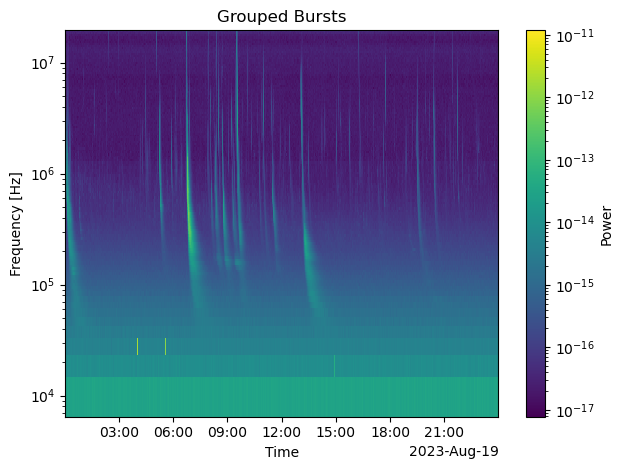

In [22]:
dyspec = data_hfr
t_fits = times_hfr
full_f_fits = np.concatenate((freq_lfr[0], freq_hfr[0]))
full_data = np.concatenate((data_lfr[:-1], data_hfr), axis = 1)

fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, full_f_fits, full_data.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
freq_log = np.logspace(np.log10(full_f_fits.min()), np.log10(full_f_fits.max()), len(full_f_fits))
freq_log_exp = np.log10(freq_log)
new_full_data = full_data.copy()
for i, data_col in enumerate(full_data):
    interpolate_func = interp1d(full_f_fits, data_col, bounds_error=False)
    data_log = interpolate_func(freq_log)
    new_full_data[i] = data_log

<Figure size 1000x600 with 0 Axes>

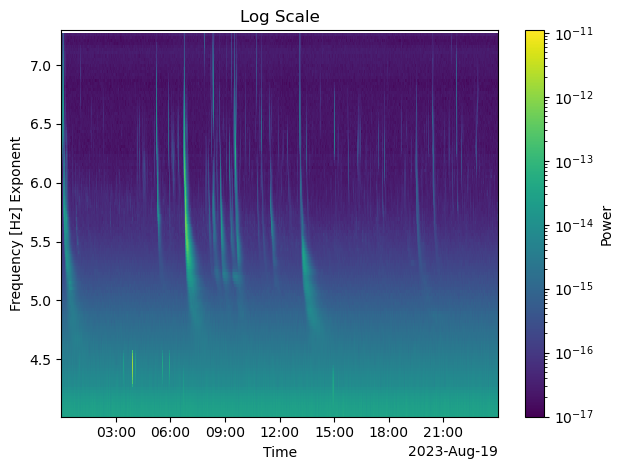

In [24]:
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, freq_log_exp, new_full_data.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz] Exponent")
# plt.yscale('log')
plt.title("Log Scale")
# plt.grid(True)
plt.tight_layout()
plt.show()

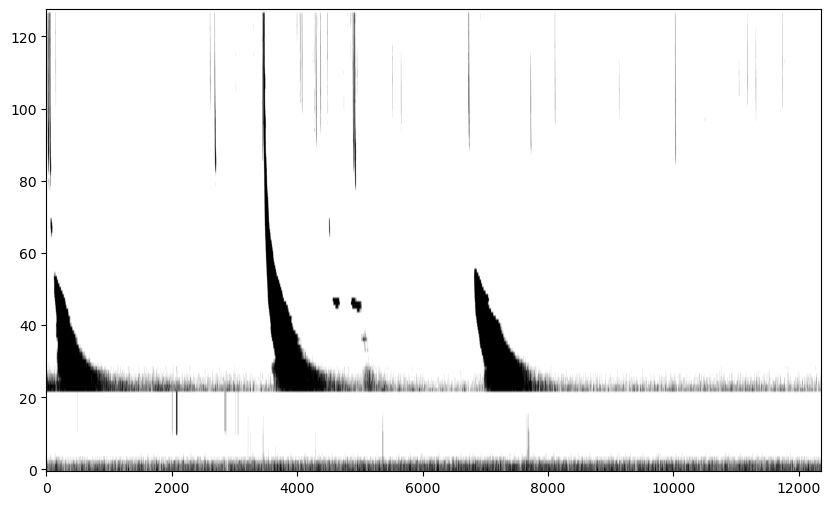

In [25]:
def bmap_row_mean_loop(full_data, ratio=1.1):
    freq_num = full_data.shape[1]
    bmap = np.zeros_like(full_data)

    for i in range(freq_num):
        row_avg = np.mean(full_data[:, i])
        row_median = np.median(full_data[:, i])
        row_std = np.std(full_data[:, i])
        bmap[:, i] = (full_data[:, i] > ratio * (row_median + row_std))

    return bmap

bmap_row_mean = bmap_row_mean_loop(new_full_data, 0.9)

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_row_mean.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

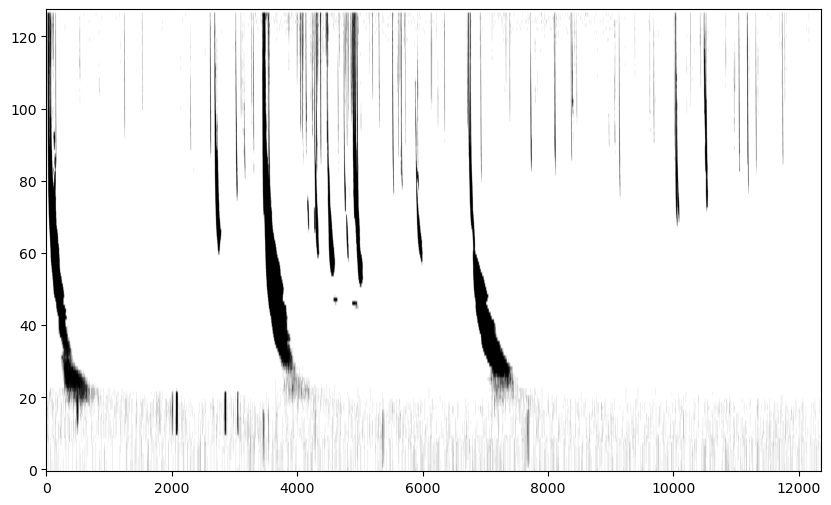

In [26]:
def bmap_row_mean_loop_new(full_data, ratio=0.95):
    freq_num = full_data.shape[1]
    bmap = np.zeros_like(full_data)

    for i in range(freq_num):
        bmap[:, i] = full_data[:, i] > np.quantile(full_data[:, i], ratio)
    
    return bmap

bmap_row_mean = bmap_row_mean_loop_new(new_full_data, 0.95)

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_row_mean.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

In [28]:
bmap_row_mean.shape

(12359, 128)

In [29]:
bmap_row_mean

array([[1., 1., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [30]:
bmap_row_mean[0][0]

1.0

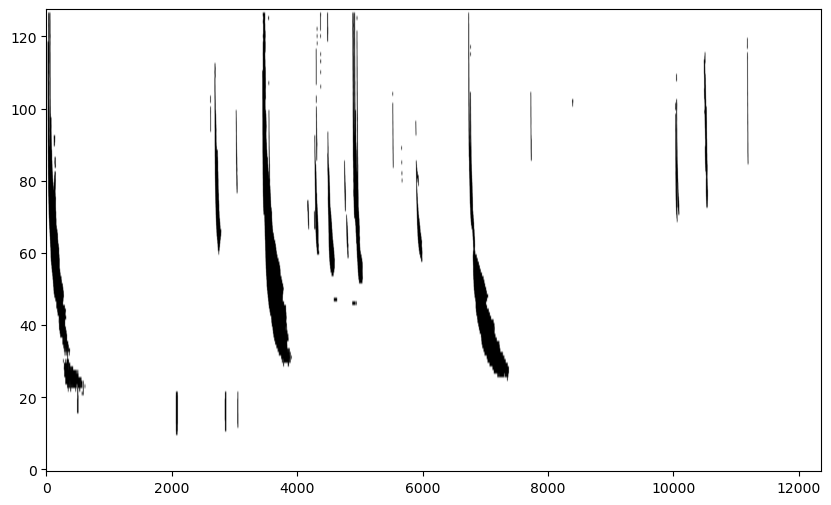

In [46]:
# To get rid off the noise at lower frequency
def bmap_row_mean_loop_new(full_data, ratio=0.95, min_length=10):
    freq_num = full_data.shape[1]
    bmap = np.zeros_like(full_data)

    for row in range(freq_num):
        bmap[:, row] = full_data[:, row] > np.quantile(full_data[:, row], ratio)

    bmap_new = np.zeros_like(bmap)
    # loop through each row
    for row in range(freq_num):
        # loop through each datapoint/column in each row
        for datapoint in range(bmap.shape[0] - min_length):
            if bmap[datapoint, row] == True:
                all_on = True
                for i in range(1, min_length+1):
                    if bmap[datapoint+i, row] == False:
                        all_on = False
                if all_on == True:
                    bmap_new[datapoint:datapoint+min_length+1, row] = True
    
    return bmap_new

bmap_row_mean = bmap_row_mean_loop_new(new_full_data, 0.95)

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_row_mean.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

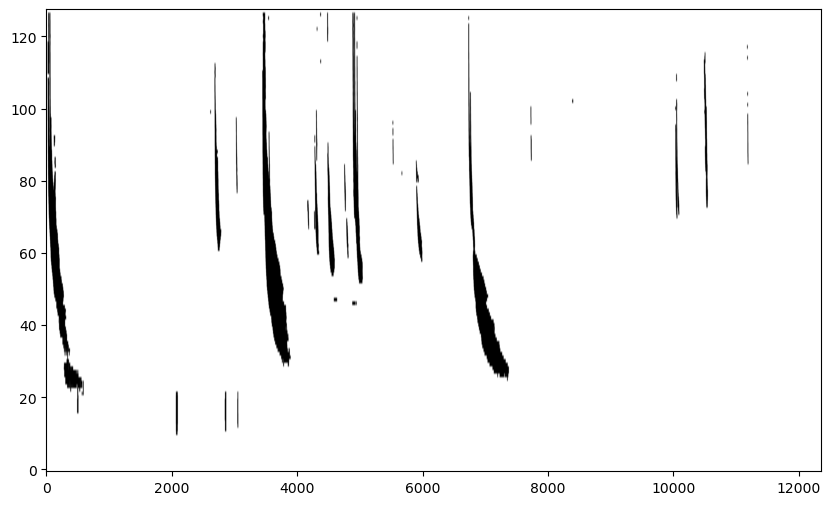

In [76]:
# time criterion
def bmap_row_mean_loop_new(full_data, ratio=0.95, min_duration=70):
    freq_num = full_data.shape[1]
    bmap = np.zeros_like(full_data)

    for row in range(freq_num):
        bmap[:, row] = full_data[:, row] > np.quantile(full_data[:, row], ratio)

    # find min_length for pixel
    time_arr_UNX = UTC_to_UNX(times_hfr)
    target_value = time_arr_UNX[0] + min_duration
    min_length = np.searchsorted(time_arr_UNX, target_value)
    
    bmap_new = np.zeros_like(bmap)
    # loop through each row
    for row in range(freq_num):
        # loop through each datapoint/column in each row
        for datapoint in range(bmap.shape[0] - min_length):
            if bmap[datapoint, row] == True:
                all_on = True
                for i in range(1, min_length+1):
                    if bmap[datapoint+i, row] == False:
                        all_on = False
                if all_on == True:
                    bmap_new[datapoint:datapoint+min_length+1, row] = True
    
    return bmap_new

bmap_row_mean = bmap_row_mean_loop_new(new_full_data, 0.95)

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_row_mean.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

In [188]:
def hough_detect(bmap,dyspec,threshold=50,line_gap=10,line_length=25,
            theta=np.linspace(np.pi/2-np.pi/8,np.pi/2-1/180*np.pi,300)):
    # trial 3:
    thresold = 10
    line_gap = 50
    line_length = 100
    theta=np.deg2rad(np.linspace(40, 60, 120))
    
    # trial 2:
    # thresold = 10
    # line_gap = 30
    # line_length = 110
    # theta=np.deg2rad(np.linspace(50, 60, 120))
    
    # trial 1:
    # thresold = 10
    # line_gap = 10
    # line_length = 120
    # theta=np.deg2rad(np.linspace(30, 40, 120))
    
    lines = probabilistic_hough_line(bmap, threshold=threshold,line_gap=line_gap,line_length=line_length,
                                 theta=theta)
    return lines

lines = hough_detect(bmap_row_mean, new_full_data)
print(lines)

[((43, 3577), (126, 3477)), ((43, 3585), (126, 3485)), ((42, 3593), (126, 3493)), ((41, 3596), (126, 3494)), ((43, 3588), (126, 3488)), ((43, 3582), (126, 3482)), ((43, 3590), (126, 3490)), ((43, 3580), (126, 3480))]


In [204]:
freq_log[1] - freq_log[0]

642.0792113066836

In [206]:
times_hfr[1]

numpy.datetime64('2023-08-19T00:00:13.814100096')

In [208]:
times_hfr[0]

numpy.datetime64('2023-08-19T00:00:06.823376640')

In [200]:
def line_grouping_new(lines, time_diff=5, freq_diff=20):
    lines = sorted(lines, key=lambda line: (line[0][0]))
    line_avg = lines[0]
    line_sets = [line_avg]
    for line in lines[1:]:
        in_group = False
        for idx, line_avg in enumerate(line_sets):
            start_time_diff = abs((line_avg[0][0] - line[0][0]) < time_diff)
            start_freq_diff = abs((line_avg[0][1] - line[0][1]) < freq_diff)
            end_time_diff = abs((line_avg[1][0] - line[1][0]) < time_diff)
            end_freq_diff = abs((line_avg[1][1] - line[1][1]) < freq_diff)
            if (start_time_diff and start_freq_diff and end_time_diff and end_freq_diff):
                in_group = True
                line_avg = (
                    (round((line_avg[0][0] + line[0][0]) / 2), round((line_avg[0][1] + line[0][1]) / 2)),
                    (round((line_avg[1][0] + line[1][0]) / 2), round((line_avg[1][1] + line[1][1]) / 2))
                )
                line_sets[idx] = line_avg
                # line_avg[0][0] = (line_avg[0][0] + line[0][0])/2
                # line_avg[0][1] = (line_avg[0][1] + line[0][1])/2
                # line_avg[1][0] = (line_avg[1][0] + line[1][0])/2
                # line_avg[1][1] = (line_avg[1][1] + line[1][1])/2
                break
        if in_group == False:
            line_sets.append(line)
        
    return line_sets

line_sets = line_grouping_new(lines, time_diff=0, freq_diff=0)
line_sets

[((41, 3596), (126, 3494)),
 ((42, 3593), (126, 3493)),
 ((43, 3577), (126, 3477)),
 ((43, 3585), (126, 3485)),
 ((43, 3588), (126, 3488)),
 ((43, 3582), (126, 3482)),
 ((43, 3590), (126, 3490)),
 ((43, 3580), (126, 3480))]

In [202]:
print(sorted(lines, key=lambda line: (line[0][0])))
print(len(lines))
print(len(line_sets))

[((41, 3596), (126, 3494)), ((42, 3593), (126, 3493)), ((43, 3577), (126, 3477)), ((43, 3585), (126, 3485)), ((43, 3588), (126, 3488)), ((43, 3582), (126, 3482)), ((43, 3590), (126, 3490)), ((43, 3580), (126, 3480))]
8
8


<Figure size 1000x600 with 0 Axes>

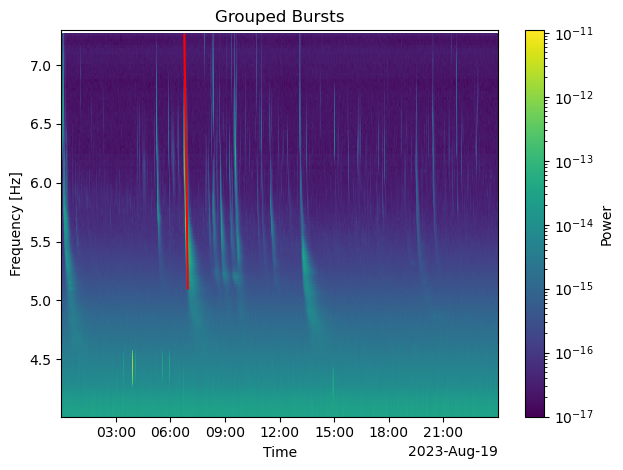

In [186]:
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, freq_log_exp, new_full_data.T, norm=LogNorm())
plt.colorbar(p, label='Power')

for (x0, y0), (x1, y1) in line_sets:
    t0, t1 = t_fits[y0], t_fits[y1]
    f0, f1 = freq_log_exp[x0], freq_log_exp[x1]
    # print(t0, t1, f0, f1)
    ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

2023-08-19T13:05:01.971621248 2023-08-19T13:11:47.421861248 5.871052723231278 7.205667754796546
2023-08-19T09:30:04.457019520 2023-08-19T09:36:00.973660288 6.025046765334963 7.256999102164441
2023-08-19T06:45:33.840211584 2023-08-19T06:52:05.309493120 5.922384070599173 7.231333428480493
2023-08-19T05:14:13.271249664 2023-08-19T05:20:02.797411072 5.588730312707856 6.897679670589177
2023-08-19T00:05:49.359058816 2023-08-19T00:11:45.875699584 5.9737154179670675 7.1543364074286515


<Figure size 1000x600 with 0 Axes>

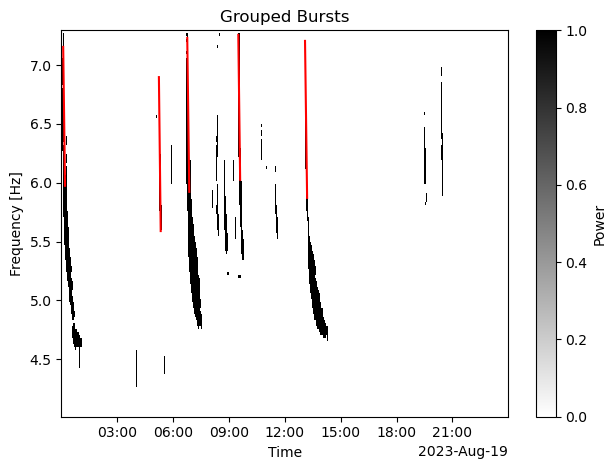

In [180]:
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, freq_log_exp, bmap_row_mean.T, shading='auto', cmap='gray_r', vmin=0, vmax=1)
plt.colorbar(p, label='Power')

for (x0, y0), (x1, y1) in line_sets:
    t0, t1 = t_fits[y0], t_fits[y1]
    f0, f1 = freq_log_exp[x0], freq_log_exp[x1]
    print(t1, t0, f0, f1)
    ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()